In [1]:
import sys
sys.path.append('..')
from osp import *


In [2]:
df_feats = pd.read_pickle('../data/raw/df_feats.pkl.gz')
df_feats.drop(columns=['weight','run'], inplace=True)
df_feats = df_feats.groupby('feature').mean(numeric_only=True).reset_index()
# df_feats['feature'] = df_feats['feature'].apply(lambda x: f'{FEAT2DESC[x]} ({x.split("_")[0]})')
df_feats = df_feats.set_index('feature')

In [10]:
feat_diff = df_feats['mean_2000-2025 Philosophy'] - df_feats['mean_1925-1950 Philosophy']

In [13]:
feat_diff

feature
deprel_acl            0.489387
deprel_acl:relcl      0.001027
deprel_advcl          0.482624
deprel_advcl:relcl    0.560541
deprel_advmod         0.286306
                        ...   
ttr_ADJ              -0.777975
ttr_ADV              -0.550373
ttr_NOUN             -0.930495
ttr_VERB             -0.834800
ttr_mean             -0.579860
Length: 99, dtype: float64

In [63]:
odf = pd.DataFrame(index=feat_diff.index)
odf['feat_diff'] = feat_diff
odf['feat_score1'] = df_feats['mean_1925-1950 Philosophy']
odf['feat_score2'] = df_feats['mean_2000-2025 Philosophy']
odf['feat_desc'] = [FEAT2DESC[x] for x in odf.index]
odf['feat_type'] = [x.split('_')[0] for x in odf.index]

top_feats = list(set(odf.sort_values('feat_diff', ascending=False).head(25).index.tolist() + odf.sort_values('feat_diff', ascending=True).head(25).index.tolist()))
top_feats += list(set(odf.sort_values('feat_score1', ascending=False).head(25).index.tolist() + odf.sort_values('feat_score2', ascending=False).head(25).index.tolist()))
odf = odf[odf.index.isin(top_feats)]
odf = odf.reset_index()


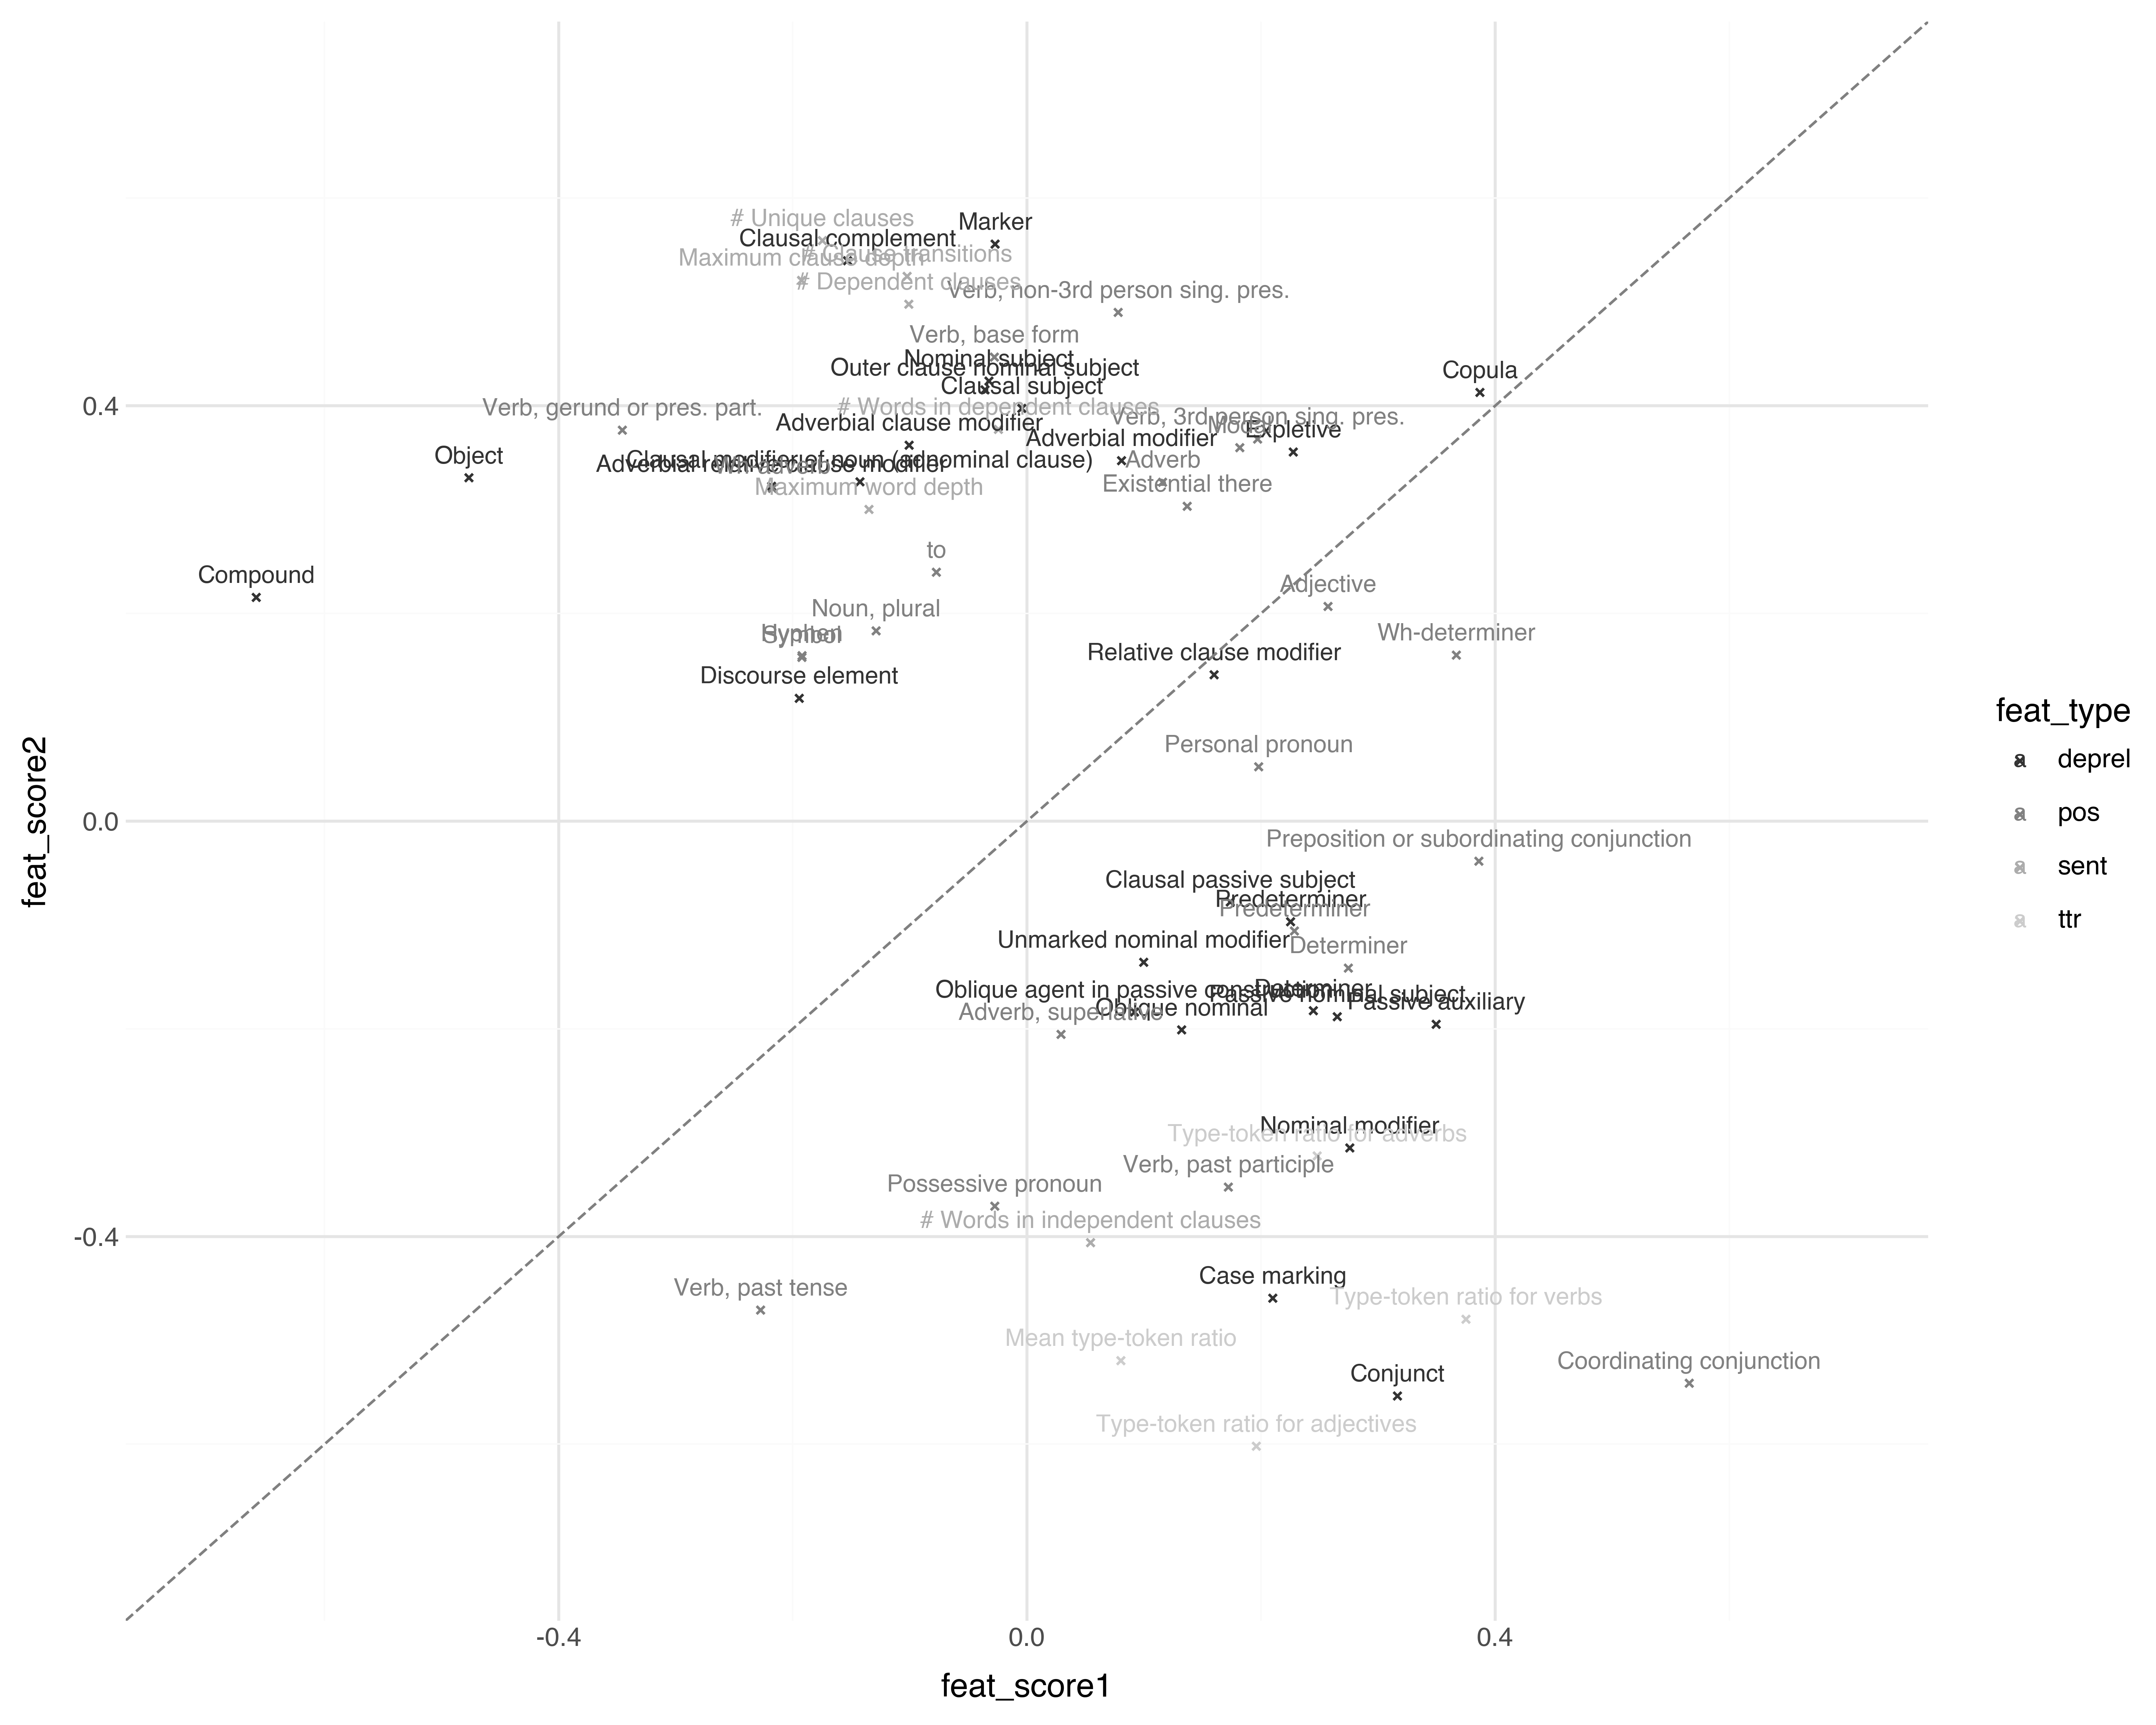

In [64]:
fig = (
    p9.ggplot(odf, p9.aes(x='feat_score1', y='feat_score2',label='feat_desc'))
    + p9.geom_point(p9.aes(color='feat_type'), size=1, position=p9.position_nudge(x=0, y=-0.02),shape='x')
    + p9.geom_text(p9.aes(color='feat_type'), size=8)#, position=p9.position_jitter(width=0.01, height=0.01))
    + p9.scale_x_continuous(limits=(-.7,.7))
    + p9.scale_y_continuous(limits=(-.7,.7))
    + p9.theme_minimal()
    + p9.geom_abline(intercept=0, slope=1, linetype='dashed', color='gray')
    + p9.scale_color_gray()
    # + p9.facet_wrap('feat_type')
)
fig